In [24]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
import subprocess

# Clone the repository
repo_url = "https://github.com/lubabasadiyanp/MedJargon-NLP-Simplifier.git"
repo_path = "/tmp/MedJargon"

# Clone if not already present
if not os.path.exists(repo_path):
    print("Cloning repository...")
    subprocess.run(['git', 'clone', repo_url, repo_path], capture_output=True)
    print("✓ Repository cloned\n")

# Load the datasets from the cloned repository
train_csv_path = os.path.join(repo_path, 'train.csv')
jargon_json_path = os.path.join(repo_path, 'jargon.json')

train_df = pd.read_csv(train_csv_path)
with open(jargon_json_path, 'r') as f:
    jargon_data = json.load(f)

print(f"✓ Train Dataset loaded: {train_df.shape[0]} rows, {train_df.shape[1]} columns")
print(f"✓ Jargon JSON loaded: {len(jargon_data)} entries\n")

print("Train Dataset Preview:")
print(train_df.head())
print(f"\nDataset Info:")
print(train_df.info())
print(f"\nJargon Data Type: {type(jargon_data)}")
if isinstance(jargon_data, list):
    print(f"Jargon Sample (first 3 entries):")
    for item in jargon_data[:3]:
        print(f"  {item}")
elif isinstance(jargon_data, dict):
    print(f"Jargon Sample (first 3 entries):")
    for key, val in list(jargon_data.items())[:3]:
        print(f"  {key}: {val}")

✓ Train Dataset loaded: 635 rows, 6 columns
✓ Jargon JSON loaded: 4511 entries

Train Dataset Preview:
   question      pmid                                         input_text  \
0         1  29857264  Exercise-Associated Muscle Cramps (EAMC) are a...   
1         1  33722257  Background: Muscle cramp is a painful, involun...   
2         1  31696455  Muscle cramp is a temporary but intense and pa...   
3         1  30168894  Muscular cramp is a common symptom in healthy ...   
4         1  29763070  Muscle cramps result in continuous, involuntar...   

                                         target_text  Adaptation_Version  \
0  Exercise-Associated Muscle Cramps (EAMC) are a...                   2   
1  Muscle cramps are unconscious contractions of ...                   2   
2  Muscle cramp is a temporary but intense, painf...                   2   
3  Muscle cramps are common in healthy people, es...                   2   
4  Muscle cramps cause constant and unintended co...        

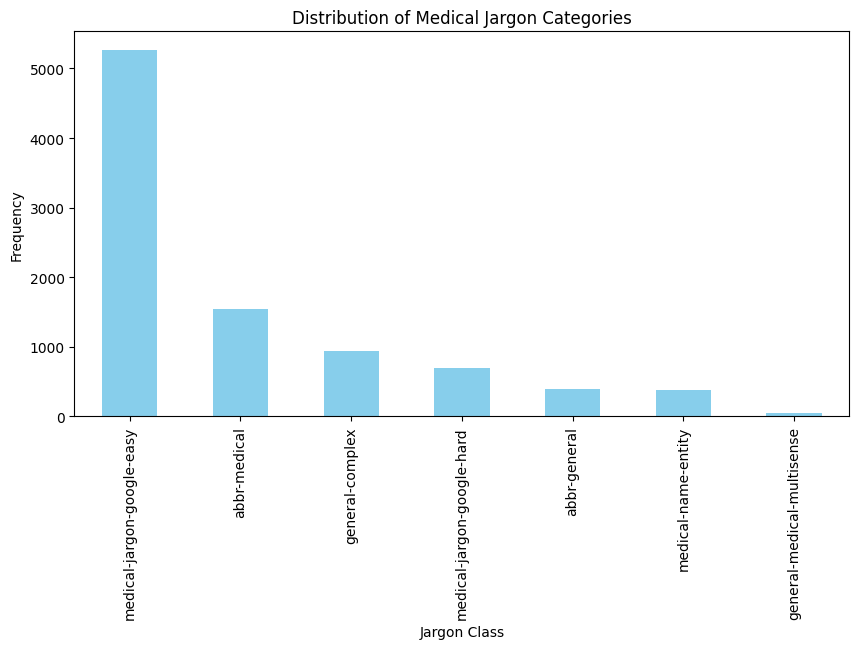

In [25]:
# Person 1 extracts the jargon labels from the JSON to see what we are dealing with
all_labels = []
for entry in jargon_data:
    for entity in entry.get('entities', []):
        all_labels.append(entity[2]) # The 3rd index is the class label

label_counts = pd.Series(all_labels).value_counts()

plt.figure(figsize=(10, 5))
label_counts.plot(kind='bar', color='skyblue')
plt.title('Distribution of Medical Jargon Categories')
plt.xlabel('Jargon Class')
plt.ylabel('Frequency')
plt.show()

In [26]:
def simple_clean(text):
    text = text.lower()
    text = re.sub(r'\[.*?\]', '', text) # Remove citations like [1, 2]
    return text.strip()

train_df['clean_input'] = train_df['input_text'].apply(simple_clean)

# Save the cleaned data for Team Members
cleaned_output_path = os.path.join(repo_path, 'cleaned_train.csv')
train_df.to_csv(cleaned_output_path, index=False)
print(f"✓ Preprocessing Complete. Cleaned data saved to {cleaned_output_path}")

✓ Preprocessing Complete. Cleaned data saved to /tmp/MedJargon/cleaned_train.csv
